# ЛЗ 6. Вероятностный прогноз сроков SaparTravel

## Объём и ограничения данных
По текущему GitHub Project в MVP 15 карточек: 4 `Done` (ST-01, ST-02, ST-03, ST-07), 1 `Review` (ST-04) и 10 `Ready` (ST-05, ST-06, ST-08–ST-15). Для симуляции `N=11`: завершённые исключены, карточка на ревью пока считается незавершённой. ST-16–ST-18 и платёжный шлюз находятся вне MVP.

Есть рассинхрон между статусами Project и issues: ST-01/02/03/07 помечены `Done` в Project, но issues открыты; ST-14 закрыт как issue, но в Project остаётся `Ready`. Число оставшихся задач здесь рассчитано по колонкам Project. Перед защитой подтвердите эти статусы с командой.

`data/throughput.csv` содержит первые 15 недельных значений учебного примера методички (из 26), а не фактическую историю команды. Сейчас выполняется ЛЗ6 на 6-й неделе курса; текущая неделя ещё не завершена, поэтому наблюдаемых недель не больше пяти. Симуляция и даты ниже демонстрируют метод на учебных значениях и не являются прогнозом SaparTravel. Для фактического прогноза замените CSV завершёнными недельными throughput-значениями команды или данными преподавателя; нулевые недели не удаляйте.

Расчётная дата — 9 октября 2026 года.

In [1]:
from datetime import date, timedelta
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
RUNS = 10_000
BACKLOG = 11  # Remaining MVP cards: ST-04, ST-05, ST-06, ST-08 ... ST-15
AS_OF = date(2026, 10, 9)

candidates = [Path.cwd() / 'data' / 'throughput.csv', Path.cwd().parent / 'data' / 'throughput.csv']
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Не найден data/throughput.csv; запустите notebook из корня проекта или папки notebooks.')

df = pd.read_csv(data_path)
required_columns = {'week_index', 'throughput'}
if not required_columns.issubset(df.columns):
    raise ValueError(f'В CSV нужны колонки {sorted(required_columns)}')
if df['throughput'].isna().any() or (df['throughput'] < 0).any():
    raise ValueError('Throughput должен содержать только неотрицательные числа без пропусков.')
history = df['throughput'].astype(int).to_numpy()
if len(history) == 0 or not np.any(history > 0):
    raise ValueError('В истории должна быть хотя бы одна неделя с завершёнными элементами.')

print(f'Источник: {data_path.resolve()}')
print(f'Недель: {len(history)}; нулевых недель: {(history == 0).sum()}')
print(f'Осталось MVP-карточек по статусам GitHub Project: {BACKLOG}')
display(df.head(10))
display(pd.DataFrame({'показатель': ['Среднее', 'Медиана', 'Минимум', 'Максимум'], 'элементов в неделю': [history.mean(), np.median(history), history.min(), history.max()]}).round(2))

Источник: /home/akira/IdeaProjects/SaparTravel/data/throughput.csv
Недель: 15; нулевых недель: 2
Осталось MVP-карточек по статусам GitHub Project: 11


,week_index,throughput
0,1,4
1,2,6
2,3,0
3,4,7
4,5,5
5,6,2
6,7,6
7,8,9
8,9,4
9,10,5


,показатель,элементов в неделю
0,Среднее,4.67
1,Медиана,5.00
2,Минимум,0.00
3,Максимум,9.00


В CSV 15 недель учебной последовательности, включая две недели с нулевым throughput. Это не фактические 15 недель SaparTravel: сейчас идёт неделя 6, и неполная неделя не должна попадать в историю. Нулевые значения в учебном ряду сохранены, чтобы показать влияние простоев; при подстановке реальных данных учитывайте только полные недели и не удаляйте их нули.

In [2]:
rng = np.random.default_rng(SEED)
weeks_to_finish = np.empty(RUNS, dtype=int)

for run in range(RUNS):
    completed = 0
    weeks = 0
    while completed < BACKLOG:
        completed += int(rng.choice(history))
        weeks += 1
    weeks_to_finish[run] = weeks

PERCENTILES = (50, 70, 85, 95)
forecast = {}
for percentile in PERCENTILES:
    forecast[percentile] = int(np.percentile(weeks_to_finish, percentile, method='higher'))

forecast_table = pd.DataFrame([
    {'Уверенность': f'P{p}', 'Недель': weeks, 'Дата': AS_OF + timedelta(weeks=weeks)}
    for p, weeks in forecast.items()
])
display(forecast_table)
print(f'Среднее число недель в симуляциях: {weeks_to_finish.mean():.2f}')
print(f'Повторяемость: seed={SEED}, прогонов={RUNS:,}, backlog={BACKLOG}')

,Уверенность,Недель,Дата
0,P50,3,2026-10-30
1,P70,3,2026-10-30
2,P85,4,2026-11-06
3,P95,5,2026-11-13


Среднее число недель в симуляциях: 2.87
Повторяемость: seed=42, прогонов=10,000, backlog=11


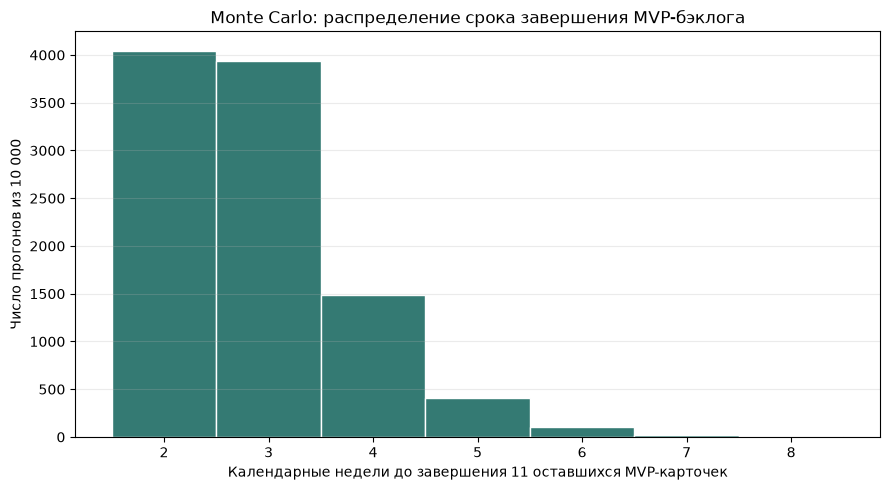

In [3]:
plt.figure(figsize=(9, 5))
bins = np.arange(weeks_to_finish.min(), weeks_to_finish.max() + 2) - 0.5
plt.hist(weeks_to_finish, bins=bins, color='#347a73', edgecolor='white')
plt.xlabel('Календарные недели до завершения 11 оставшихся MVP-карточек')
plt.ylabel('Число прогонов из 10 000')
plt.title('Monte Carlo: распределение срока завершения MVP-бэклога')
plt.xticks(np.arange(weeks_to_finish.min(), weeks_to_finish.max() + 1))
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

**Вывод по гистограмме.** Каждый столбец показывает, сколько из 10 000 случайных траекторий завершили backlog за соответствующее число недель. Это распределение возможных сроков при условии, что будущий throughput похож на учебную историю; оно не гарантирует конкретную дату. Нулевые недели увеличивают правый хвост.

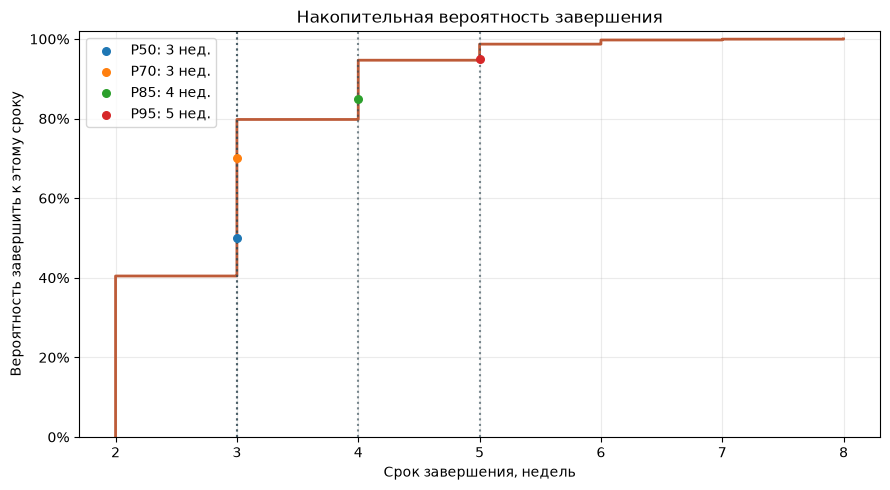

In [4]:
sorted_weeks = np.sort(weeks_to_finish)
cumulative_probability = np.arange(1, RUNS + 1) / RUNS
plt.figure(figsize=(9, 5))
plt.step(sorted_weeks, cumulative_probability, where='post', color='#bd5b38', linewidth=2)
for percentile, weeks in forecast.items():
    probability = percentile / 100
    plt.axvline(weeks, linestyle=':', alpha=0.65, color='#344b55')
    plt.scatter([weeks], [probability], s=30, zorder=3, label=f'P{percentile}: {weeks} нед.')
plt.xlabel('Срок завершения, недель')
plt.ylabel('Вероятность завершить к этому сроку')
plt.title('Накопительная вероятность завершения')
plt.ylim(0, 1.02)
plt.yticks(np.linspace(0, 1, 6), [f'{value:.0%}' for value in np.linspace(0, 1, 6)])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по накопительной кривой.** Для любой выбранной даты по оси X кривая показывает долю симуляций, в которых backlog завершён не позднее неё. Например, точка P85 означает: при принятых допущениях 85% прогонов завершились к указанному сроку, а в 15% случаев потребовалось больше времени. Для планирования с заказчиком разумно обсуждать пару уровней уверенности, а не одну дату.

In [5]:
# Учебное сопоставление для тех же 11 незавершённых MVP-карточек; velocity команды не измерена.
REMAINING_STORY_POINTS = {
    'ST-04': 8, 'ST-05': 3, 'ST-06': 8, 'ST-08': 8, 'ST-09': 8,
    'ST-10': 5, 'ST-11': 3, 'ST-12': 3, 'ST-13': 3, 'ST-14': 5, 'ST-15': 3,
}
BACKLOG_STORY_POINTS = sum(REMAINING_STORY_POINTS.values())
ASSUMED_VELOCITY_SP_PER_WEEK = 8
story_point_weeks = math.ceil(BACKLOG_STORY_POINTS / ASSUMED_VELOCITY_SP_PER_WEEK)
mean_throughput_weeks = BACKLOG / history.mean()
comparison = pd.DataFrame([
    {'Подход': 'Деление оставшегося backlog на средний throughput', 'Расчётный срок, недель': f'{mean_throughput_weeks:.2f}', 'Статус': 'Ориентир по среднему, не уровень уверенности'},
    {'Подход': 'Story points / условная velocity (11 оставшихся карточек)', 'Расчётный срок, недель': f'{story_point_weeks} (округление вверх)', 'Статус': f'{BACKLOG_STORY_POINTS} SP / 8 SP в неделю; velocity пока допущение'},
    {'Подход': 'Monte Carlo P85', 'Расчётный срок, недель': str(forecast[85]), 'Статус': '85% учебных прогонов завершились не позднее срока'},
])
display(comparison)
print('WBS оценивает полный проект в 171 человеко-час на 12 недель; эти часы нельзя прямо приравнять к оставшимся MVP-карточкам или story points.')

,Подход,"Расчётный срок, недель",Статус
0,Деление оставшегося backlog на средний throughput,2.36,"Ориентир по среднему, не уровень уверенности"
1,Story points / условная velocity (11 оставшихс...,8 (округление вверх),57 SP / 8 SP в неделю; velocity пока допущение
2,Monte Carlo P85,4,85% учебных прогонов завершились не позднее срока


WBS оценивает полный проект в 171 человеко-час на 12 недель; эти часы нельзя прямо приравнять к оставшимся MVP-карточкам или story points.


## Сопоставление и ограничения
Для оставшихся 11 карточек расчёт `11 / средний учебный throughput` даёт примерно 2,36 недели, но это только деление на среднее, а не оценка вероятности. Учебные оценки тех же незавершённых историй составляют 57 SP; при условной, не измеренной скорости 8 SP/неделю это 8 недель с округлением вверх. Оба срока основаны на допущениях: throughput-серия учебная, story points условны, а команда ещё не накопила стабильную собственную velocity.

Расхождение ожидаемо: throughput считает завершённые карточки одинаковыми, хотя размеры различаются; среднее скрывает нулевые и слабые недели; velocity взята как допущение, а не из наблюдений. Полный WBS проекта оценивается в 171 человеко-час на 12 недель и включает работы за пределами оставшихся 11 MVP-карточек, поэтому напрямую сравнивать эти единицы нельзя.

### Решение по плану
Считать N по незавершённым карточкам Project: сейчас 11, включая ST-04 в Review. Перед обещанием срока заказчику подтвердить рассинхрон статусов Project/Issues, заменить демонстрационный throughput реальными недельными данными и затем пересчитать прогноз. Пока диапазон служит только учебной демонстрацией.